# ResNet50 PyTorch Local GPU Training
**Pipeline:** ResNet50 ImageNet backbone -> 128-d embedding head -> 6-class classifier  
Training uses local laptop GPU, Keras-equivalent augmentation, full metric reporting, plots, inference timing, model size/parameter reporting, and saved embeddings/results.  
All outputs saved to `ResNet50Results/`.


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library ──────────────────────────────────────────
# os, pathlib : file path construction and directory management
# time        : wall-clock timing for inference benchmarking
import os
import time
from pathlib import Path


# ── Scientific computing ───────────────────────────────────────
# numpy  : array operations, random sampling, metric aggregation
# pandas : tabular results and CSV export
# matplotlib: training curve and metric plot generation
# tqdm   : progress bars for training and evaluation loops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch core ───────────────────────────────────────────────
# torch           : tensor operations and autograd engine
# torch.nn        : layer definitions (Linear, Dropout, Identity)
# torch.optim     : Adam optimiser
# torch.nn.functional: softmax for probability conversion
# DataLoader/Subset: batch loading and index-based subset sampling
# torchvision     : pretrained ResNet50 weights and transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights


# ── Evaluation metrics ─────────────────────────────────────────
# sklearn: classification report, confusion matrix, per-class
#         precision/recall/F1 for full evaluation pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)


# ── Dataset and output paths ───────────────────────────────────
# Dataset is pre-split into Training / Validation / Testing.
# All results (model weights, plots, CSVs) are saved to OUTPUT_DIR.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "ResNet50_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Training hyperparameters ───────────────────────────────────
# IMG_SIZE=224      : ResNet50 standard input resolution
# BATCH_SIZE=32     : balances GPU memory usage and gradient noise
# EPOCHS=50         : maximum epochs (early stopping usually stops earlier)
# PATIENCE=5        : stop if val_loss does not improve for 5 consecutive epochs
# MIN_EPOCHS_BEFORE_STOP=20: ensures meaningful training before early stop
# LR=1e-5           : low learning rate for stable fine-tuning of pretrained weights
# SEED=42           : fixed random seed for fully reproducible splits and weights
# EMBED_DIM=128     : dimensionality of the custom classification head embedding
# TRAIN_PER_CLASS=1750, VAL_PER_CLASS=250: balanced split (500 test per class)
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-5
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
EMBED_DIM       = 128
NUM_WORKERS     = 0
USE_PRETRAINED  = True
REQUIRE_CUDA    = True


# ── Device configuration ───────────────────────────────────────
# REQUIRE_CUDA=True ensures training always runs on GPU.
# cudnn.benchmark=True lets cuDNN auto-tune convolution kernels
# for the fixed input size, improving throughput after first batch.
# PIN_MEMORY=True speeds up CPU->GPU data transfer via page-locked memory.
# ── Device setup ────────────────────────────────
if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Open this notebook in the GPU-enabled PyTorch environment, check nvidia-smi, then rerun.")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    PIN_MEMORY = True
    torch.backends.cudnn.benchmark = True
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1e9
else:
    DEVICE = torch.device("cpu")
    PIN_MEMORY = False
    gpu_name = "CUDA not available"
    gpu_memory_gb = 0.0


# Fix all random seeds for reproducibility across numpy, PyTorch, and CUDA
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Device information")
print("=" * 50)
print(f"Device used       : {DEVICE}")
print(f"Device type       : {DEVICE.type}")
print(f"Graphics card/GPU : {gpu_name}")
if torch.cuda.is_available():
    print(f"GPU memory        : {gpu_memory_gb:.1f} GB")
    print(f"CUDA version      : {torch.version.cuda}")
print(f"PyTorch version   : {torch.__version__}")
print("=" * 50)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results
Device information
Device used       : cuda
Device type       : cuda
Graphics card/GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU memory        : 4.0 GB
CUDA version      : 12.4
PyTorch version   : 2.6.0+cu124


In [2]:
# ================================================
# Cell 2 — Dataset Loading + Augmentation
# ================================================
# ── Custom dataset class ───────────────────────────────────────
# torchvision ImageFolder sorts classes alphabetically by default,
# which would order them as 0,1000,1500,100,2000,500 (string sort).
# OrderedImageFolder overrides find_classes() to enforce the correct
# numeric milling order: 0, 100, 500, 1000, 1500, 2000.
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Training augmentation pipeline ─────────────────────────────
# Online augmentation is applied randomly at each epoch to improve
# generalisation and reduce overfitting on the aggregate images.
# RandomHorizontalFlip : aggregate orientation is arbitrary
# RandomRotation(20)   : simulate varied camera angles
# RandomAffine(scale)  : simulate varying specimen-to-camera distance
# Normalize(ImageNet)  : required for pretrained ResNet50 backbone
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Evaluation transform (no augmentation) ─────────────────────
# Validation, test, and embedding-extraction passes use a
# deterministic transform: only resize and ImageNet normalisation.
# No augmentation ensures consistent and reproducible evaluation.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Load pre-split datasets ────────────────────────────────────
# Dataset was split offline (SEED=42) into mutually exclusive
# train/val/test folders before training — no random splitting here.
# train_eval_ds uses eval_transform on training images for
# embedding extraction without augmentation noise.
# Load directly from pre-split folders (no Subset needed)
train_ds      = OrderedImageFolder(root=TRAIN_PATH, transform=train_transform)
train_eval_ds = OrderedImageFolder(root=TRAIN_PATH, transform=eval_transform)
val_ds        = OrderedImageFolder(root=VAL_PATH,   transform=eval_transform)
test_ds       = OrderedImageFolder(root=TEST_PATH,  transform=eval_transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# ── DataLoaders ────────────────────────────────────────────────
# train_loader shuffles batches each epoch for stochastic gradient descent.
# val/test loaders are unshuffled for deterministic evaluation.
# pin_memory=True and num_workers accelerate GPU data transfer.
train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader       = DataLoader(test_ds,       batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Data loaders ready.")
print("Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2")

Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.
Augmentation: horizontal flip, rotation ±20°, zoom 0.8–1.2


In [3]:
# ================================================
# Cell 3 — Model: ResNet50 + 128-d Embedding Head
# ================================================
# ── Model architecture ─────────────────────────────────────────
# ResNet50 ImageNet backbone with a custom 3-layer classification head.
# The original fc layer (2048->1000) is replaced with nn.Identity()
# to expose the 2048-d feature vector for the custom head.
# Custom head: Dropout(0.3) -> Linear(2048->128) -> ReLU -> Linear(128->6)
# The 128-d embedding layer serves a dual purpose:
#   1. Dimensionality reduction before the 6-class output
#   2. Feature embedding for PCA analysis and SVM training
# return_embedding=True returns both logits and the 128-d embedding.
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=6, embedding_dim=128, p_drop=0.3, use_pretrained=True):
        super().__init__()
        # Load ImageNet pretrained weights if USE_PRETRAINED=True.
        # Falls back to random initialisation if weights cannot be fetched.
        weights = None
        if use_pretrained:
            try:
                weights = ResNet50_Weights.IMAGENET1K_V2
                self.backbone = resnet50(weights=weights)
                print("Loaded ResNet50 ImageNet pretrained weights.")
            except Exception as exc:
                print(f"Could not load pretrained weights ({exc}). Using random initialization.")
                self.backbone = resnet50(weights=None)
        else:
            self.backbone = resnet50(weights=None)

        # Store in_features (2048 for ResNet50) BEFORE replacing fc
        in_features = self.backbone.fc.in_features
        # Replace the original fc head with Identity to expose 2048-d features
        self.backbone.fc = nn.Identity()
        # Custom head: reduces 2048-d features to 128-d embedding with regularisation
        self.embedding_head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
        )
        # Final linear layer maps 128-d embedding to 6-class logits
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        emb = self.embedding_head(features)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits

model = ResNet50Classifier(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBED_DIM,
    p_drop=0.3,
    use_pretrained=USE_PRETRAINED,
).to(DEVICE)


# CrossEntropyLoss combines LogSoftmax + NLLLoss — standard for multi-class
# Adam optimiser with lr=1e-5 for stable fine-tuning of pretrained weights
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
TRAINABLE_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {TOTAL_PARAMS:,}")
print(f"Trainable parameters: {TRAINABLE_PARAMS:,}")
print(f"Embedding dimension : {EMBED_DIM}")


Loaded ResNet50 ImageNet pretrained weights.
Total parameters    : 23,771,078
Trainable parameters: 23,771,078
Embedding dimension : 128


/tmp/ipykernel_6725/774216412.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_6725/774216412.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_6725/774216412.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Epoch 26/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 26]  Train Acc: 0.8834  Val Acc: 0.8500  Train Loss: 0.2926  Val Loss: 0.3671


Epoch 27/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 27/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 27]  Train Acc: 0.8883  Val Acc: 0.8593  Train Loss: 0.2771  Val Loss: 0.3649
Early stopping at epoch 27 after 5 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results/best_resnet50_model.pth


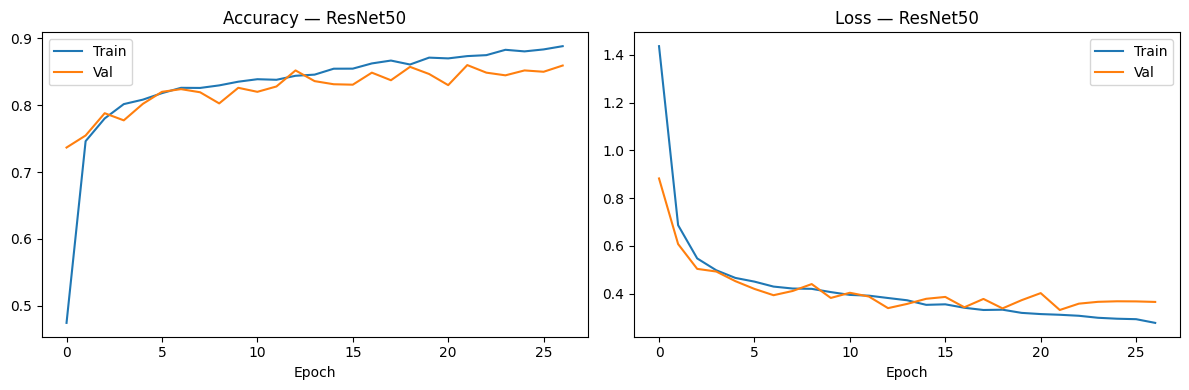

Training curves saved.
Training history saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_resnet50_model.pth")

# ── Automatic Mixed Precision (AMP) ────────────────────────────
# AMP runs forward passes in float16 where safe, and float32 where
# needed for numerical stability. GradScaler prevents gradient underflow.
# Typically gives 1.5-2x speedup on modern NVIDIA GPUs with no accuracy loss.
use_amp = DEVICE.type == "cuda"
scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

# ── Early stopping state ───────────────────────────────────────
# Track best validation loss and count epochs without improvement.
# Best model weights are saved to disk whenever val_loss improves.
best_val_loss = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop ──────────────────────────────────────────────
# Each epoch: (1) train one full pass, (2) evaluate on validation set,
# (3) check early stopping condition, (4) save best model if improved.
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        # torch.no_grad() disables gradient tracking during inference,
        # reducing memory usage and speeding up evaluation.
        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    # torch.no_grad() disables gradient tracking during inference,
    # reducing memory usage and speeding up evaluation.
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping: train at least 20 epochs, then stop after 5 no-improvement epochs ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# ── Learning curves ────────────────────────────────────────────
# Plot and save training/validation accuracy and loss per epoch.
# Curves are saved as PNG and history exported to CSV for analysis.
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train')
axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — ResNet50")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(train_loss_hist, label='Train')
axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — ResNet50")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")

pd.DataFrame({
    "epoch": range(1, len(train_loss_hist) + 1),
    "train_loss": train_loss_hist,
    "val_loss": val_loss_hist,
    "train_acc": train_acc_hist,
    "val_acc": val_acc_hist,
}).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
print("Training history saved.")


In [5]:
# ================================================
# Cell 5 — Model / Device / Size Summary
# ================================================
# Helper to read saved model file size in megabytes
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2) if os.path.exists(path) else np.nan

MODEL_SIZE_MB = get_file_size_mb(BEST_MODEL_PATH)


# ── Model and device summary ───────────────────────────────────
# Captures all training environment details and model properties
# in a single CSV for reproducibility and result reporting.
summary = {
    "model": "ResNet50 PyTorch",
    "device_used": str(DEVICE),
    "device_type": DEVICE.type,
    "graphics_card": gpu_name,
    "gpu_memory_gb": round(gpu_memory_gb, 3),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": round(MODEL_SIZE_MB, 3),
    "embedding_dim": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "image_size": IMG_SIZE,
    "epochs_configured": EPOCHS,
    "patience": PATIENCE,
    "min_epochs_before_stop": MIN_EPOCHS_BEFORE_STOP,
    "best_model_path": BEST_MODEL_PATH,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "model_device_size_summary.csv"), index=False)

print("\nMODEL / DEVICE / SIZE SUMMARY")
print("=" * 70)
for k, v in summary.items():
    print(f"{k:24}: {v}")
print("=" * 70)



MODEL / DEVICE / SIZE SUMMARY
model                   : ResNet50 PyTorch
device_used             : cuda
device_type             : cuda
graphics_card           : NVIDIA GeForce RTX 3050 Ti Laptop GPU
gpu_memory_gb           : 3.963
torch_version           : 2.6.0+cu124
cuda_version            : 12.4
total_parameters        : 23771078
trainable_parameters    : 23771078
model_size_mb           : 90.991
embedding_dim           : 128
batch_size              : 32
image_size              : 224
epochs_configured       : 50
patience                : 5
min_epochs_before_stop  : 20
best_model_path         : /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results/best_resnet50_model.pth



     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0           500       NO 
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0             0       YES
    12             0             0       YES
    13             0             0       YES
    14             0             0       YES
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0             0       YES
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_6725/694731957.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


    32             0             0       YES
    33             0             0       YES
    34             0             0       YES
    35             0             0       YES
    36             0             0       YES
    37             0             0       YES
    38             0             0       YES
    39             0           500       NO 
    40             0             0       YES
    41             0             0       YES
    42             0             0       YES
    43             0             0       YES
    44             0             0       YES
    45             0             0       YES
    46             0             0       YES
    47             0             0       YES
    48             0             0       YES
    49             0             0       YES
    50             0             0       YES
    51             0             0       YES
    52             0             0       YES
    53             0             0       YES
    54    

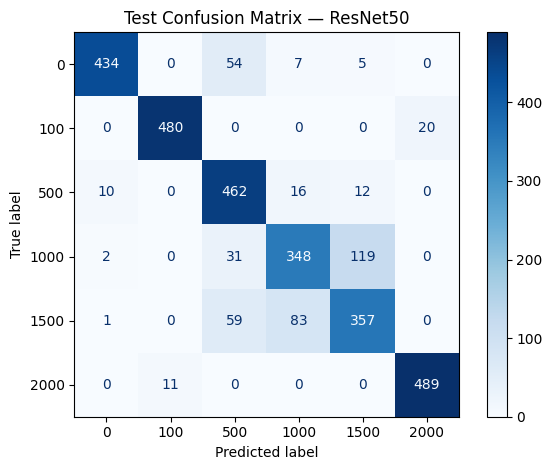


Classification Report — ResNet50:
              precision    recall  f1-score   support

           0     0.9709    0.8680    0.9166       500
         100     0.9776    0.9600    0.9687       500
         500     0.7624    0.9240    0.8354       500
        1000     0.7665    0.6960    0.7296       500
        1500     0.7241    0.7140    0.7190       500
        2000     0.9607    0.9780    0.9693       500

    accuracy                         0.8567      3000
   macro avg     0.8604    0.8567    0.8564      3000
weighted avg     0.8604    0.8567    0.8564      3000



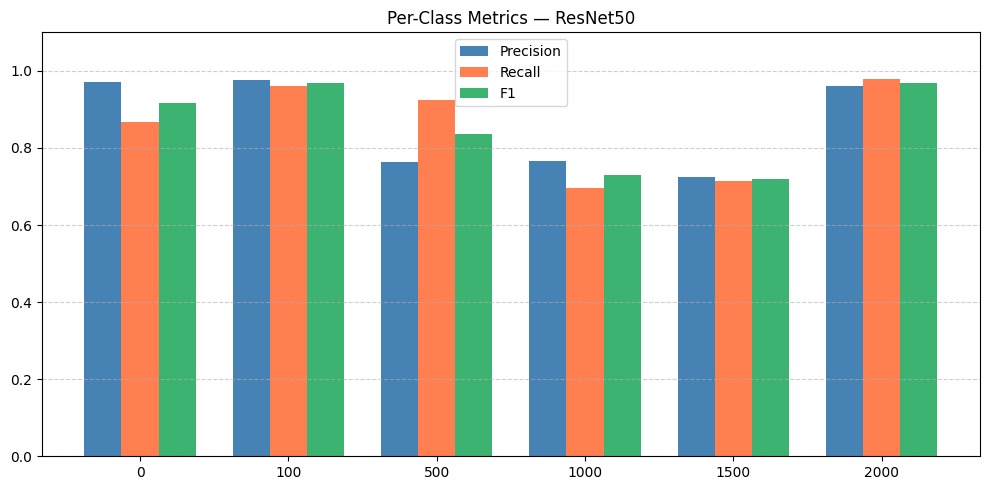

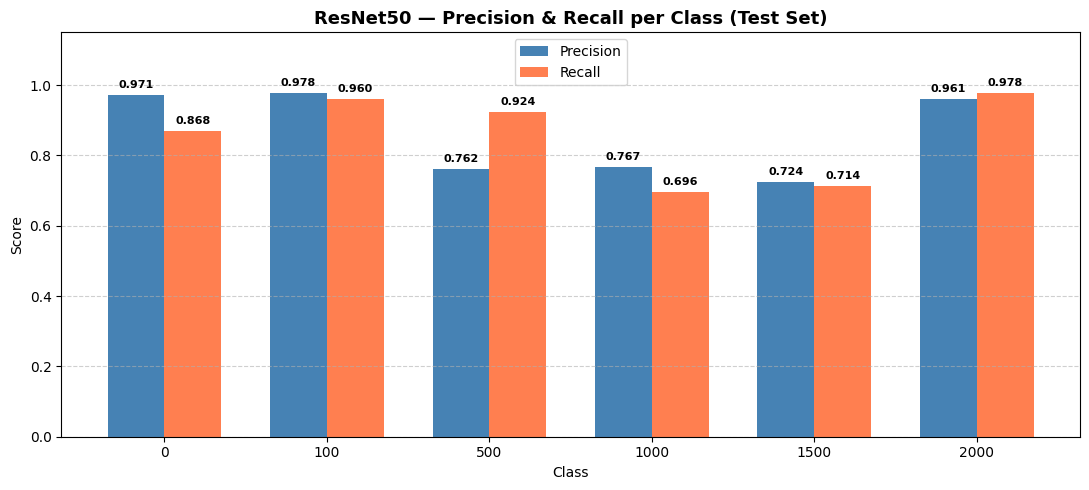

Precision & recall graph saved.


/tmp/ipykernel_6725/694731957.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_6725/694731957.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



ResNet50 — Inference Time per Image
  Images timed : 100
  Average      : 5.564 ms / image
  Std Dev      : 0.878 ms
  Min          : 4.761 ms
  Max          : 9.343 ms

FINAL SUMMARY
Accuracy           : 85.67%
Macro Precision    : 86.04%
Macro Recall       : 85.67%
Macro F1-score     : 85.64%
Parameters         : 23,771,078 total | 23,771,078 trainable
Model size         : 90.991 MB
Inference time     : 5.564 ms/image
Device             : cuda | NVIDIA GeForce RTX 3050 Ti Laptop GPU
Results saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results


In [6]:
# ================================================
# Cell 6 — Test Evaluation + Reports + Graphs + Inference Time
# ================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (ResNet50): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# ── Confusion matrix ───────────────────────────────────────────
# Shows predicted vs true class counts for all 6 milling classes.
# Off-diagonal entries reveal which classes are most confused.
# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — ResNet50")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_resnet50.png"), dpi=150)
plt.show()


# ── Full classification report ─────────────────────────────────
# Per-class precision, recall, F1-score and support.
# Saved as both .txt (human-readable) and .csv (for analysis).
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — ResNet50:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_resnet50.txt"), "w") as f:
    f.write(report_txt)
report_df = pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report_resnet50.csv"))


# ── Per-class metric bar charts ────────────────────────────────
# Grouped bar charts show precision, recall and F1 side by side
# for each milling class, highlighting inter-class performance gaps.
# ── Per-class metrics ──
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall = recall_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
f1 = f1_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, w, label='Precision', color='steelblue')
plt.bar(x, recall, w, label='Recall', color='coral')
plt.bar(x + w, f1, w, label='F1', color='mediumseagreen')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — ResNet50")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_resnet50.png"), dpi=150)
plt.show()

w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, recall, w2, label='Recall', color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, precision[i] + 0.02, f'{precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, recall[i] + 0.02, f'{recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.15)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("ResNet50 — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_resnet50.png"), dpi=150)
plt.show()
print("Precision & recall graph saved.")


# ── Save raw predictions and class probabilities ───────────────
# Exports per-sample predictions with softmax probabilities for
# all 6 classes — used for downstream analysis and error inspection.
# ── Raw predictions CSV ──
pred_df = pd.DataFrame({
    "Sample": range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct": (all_preds == all_labels).astype(int),
})
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pred_df[f"Prob_{cls_name}"] = all_probs[:, cls_idx]
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions_resnet50.csv"), index=False)

# ================================================
# Inference Time — 100 random test samples, per image
# ================================================
num_timing = min(100, len(test_ds))
_rng100 = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_ds), num_timing, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    _warm = _warm.to(DEVICE)
    with torch.cuda.amp.autocast(enabled=use_amp):
        _ = model(_warm)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

inference_times_ms = []
model.eval()
# torch.no_grad() disables gradient tracking during inference,
# reducing memory usage and speeding up evaluation.
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast(enabled=use_amp):
            _ = model(_inp)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        inference_times_ms.append((time.perf_counter() - _t0) * 1000)

avg_time_ms = float(np.mean(inference_times_ms))
std_time_ms = float(np.std(inference_times_ms))

print("\n" + "="*58)
print("ResNet50 — Inference Time per Image")
print("="*58)
print(f"  Images timed : {num_timing}")
print(f"  Average      : {avg_time_ms:.3f} ms / image")
print(f"  Std Dev      : {std_time_ms:.3f} ms")
print(f"  Min          : {np.min(inference_times_ms):.3f} ms")
print(f"  Max          : {np.max(inference_times_ms):.3f} ms")
print("="*58)

pd.DataFrame({"sample": range(num_timing), "inference_time_ms": inference_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "resnet50_inference_times.csv"), index=False)
pd.DataFrame({
    "Stage": ["ResNet50"],
    "Avg_ms_per_image": [round(avg_time_ms, 4)],
    "Std_ms": [round(std_time_ms, 4)],
    "Min_ms": [round(float(np.min(inference_times_ms)), 4)],
    "Max_ms": [round(float(np.max(inference_times_ms)), 4)],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)


# ── Aggregate metrics summary ──────────────────────────────────
# Computes macro and weighted averages across all 6 classes and
# exports all metrics together with model and device info to CSV.
# ── Final metrics summary ──
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

metrics_summary = pd.DataFrame([{
    "accuracy": test_acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,
    "avg_inference_ms_per_image": avg_time_ms,
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": MODEL_SIZE_MB,
    "device_used": str(DEVICE),
    "graphics_card": gpu_name,
}])
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_resnet50.csv"), index=False)

print("\nFINAL SUMMARY")
print("=" * 70)
print(f"Accuracy           : {test_acc * 100:.2f}%")
print(f"Macro Precision    : {macro_precision * 100:.2f}%")
print(f"Macro Recall       : {macro_recall * 100:.2f}%")
print(f"Macro F1-score     : {macro_f1 * 100:.2f}%")
print(f"Parameters         : {TOTAL_PARAMS:,} total | {TRAINABLE_PARAMS:,} trainable")
print(f"Model size         : {MODEL_SIZE_MB:.3f} MB")
print(f"Inference time     : {avg_time_ms:.3f} ms/image")
print(f"Device             : {DEVICE} | {gpu_name}")
print("=" * 70)
print("Results saved in:", OUTPUT_DIR)


In [7]:
# ================================================
# Cell 7 — Feature Extraction  (save embeddings)
# ================================================
# ── Embedding extraction ───────────────────────────────────────
# Passes each split through the model with return_embedding=True
# to extract 128-d feature vectors from the penultimate layer.
# Embeddings are saved as .npy files for:
#   - PCA visualisation (Cell 9)
#   - SVM classifier training (Hybrid notebook)
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    # torch.no_grad() disables gradient tracking during inference,
    # reducing memory usage and speeding up evaluation.
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                _, emb = model(inputs, return_embedding=True)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

train_embs, train_y = extract_embeddings(train_eval_loader, model, "train")
val_embs, val_y = extract_embeddings(val_loader, model, "val")
test_embs, test_y = extract_embeddings(test_loader, model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [
    ("train_embs", train_embs), ("val_embs", val_embs), ("test_embs", test_embs),
    ("train_y", train_y), ("val_y", val_y), ("test_y", test_y),
]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")


Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_6725/406030973.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 128)  val: (1500, 128)  test: (3000, 128)
  Saved train_embs.npy  shape=(10500, 128)
  Saved val_embs.npy  shape=(1500, 128)
  Saved test_embs.npy  shape=(3000, 128)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


In [8]:
# ================================================
# Cell 8 — Saved Artifact Listing
# ================================================
# List all files saved to OUTPUT_DIR with their sizes for verification
print("\n" + "="*60)
print("ResNet50 saved artifacts")
print("="*60)
for item in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, item)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"{item:45} {size_mb:10.3f} MB")
    else:
        print(item)
print("="*60)



ResNet50 saved artifacts
best_resnet50_model.pth                           90.991 MB
classification_report_resnet50.csv                 0.001 MB
classification_report_resnet50.txt                 0.001 MB
confusion_matrix_resnet50.png                      0.050 MB
inference_time_summary.csv                         0.000 MB
metrics_summary_resnet50.csv                       0.000 MB
model_device_size_summary.csv                      0.000 MB
per_class_metrics_resnet50.png                     0.029 MB
precision_recall_resnet50.png                      0.049 MB
predictions_resnet50.csv                           0.189 MB
resnet50_inference_times.csv                       0.002 MB
test_embs.npy                                      1.465 MB
test_y.npy                                         0.023 MB
train_embs.npy                                     5.127 MB
train_y.npy                                        0.080 MB
training_curves.png                                0.066 MB
training_histo

Embeddings : (3000, 128)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results/PCA_Analysis

Explained variance: PC1=0.498  PC2=0.265  Total=0.763


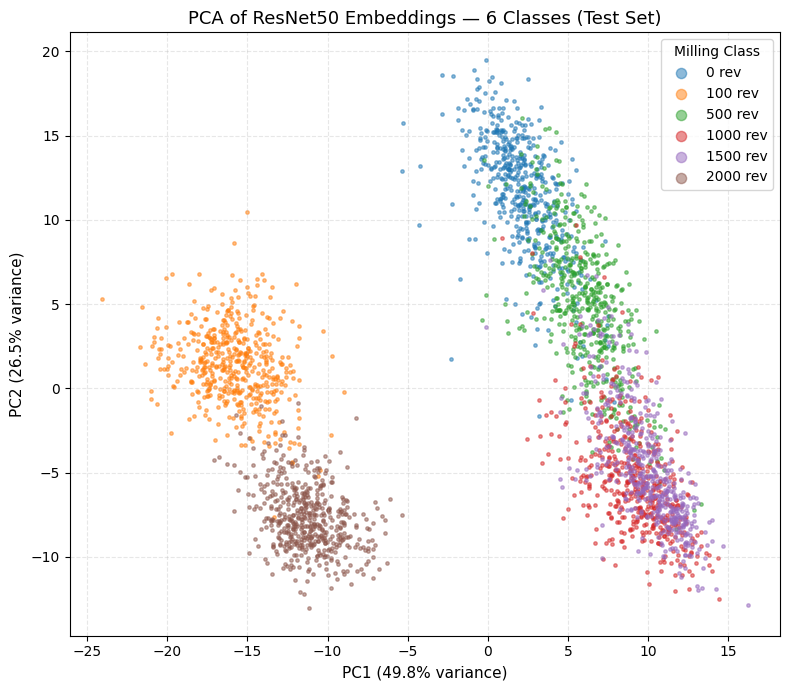

Saved: pca_embeddings.png


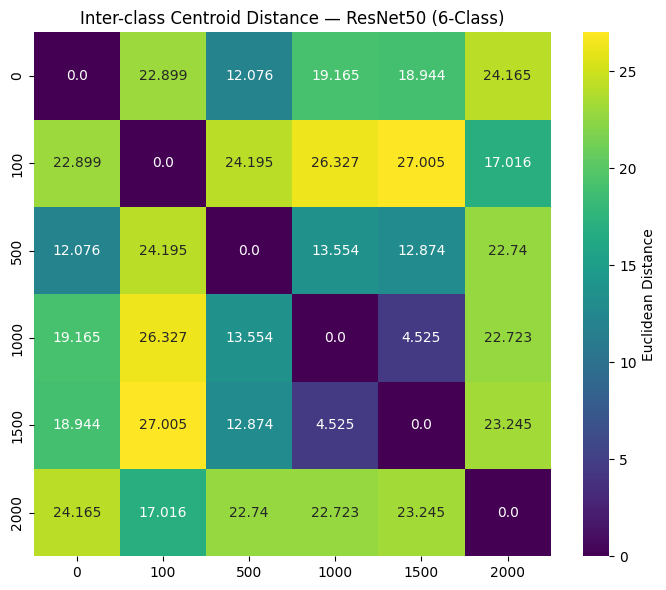

Saved: distance_heatmap.png


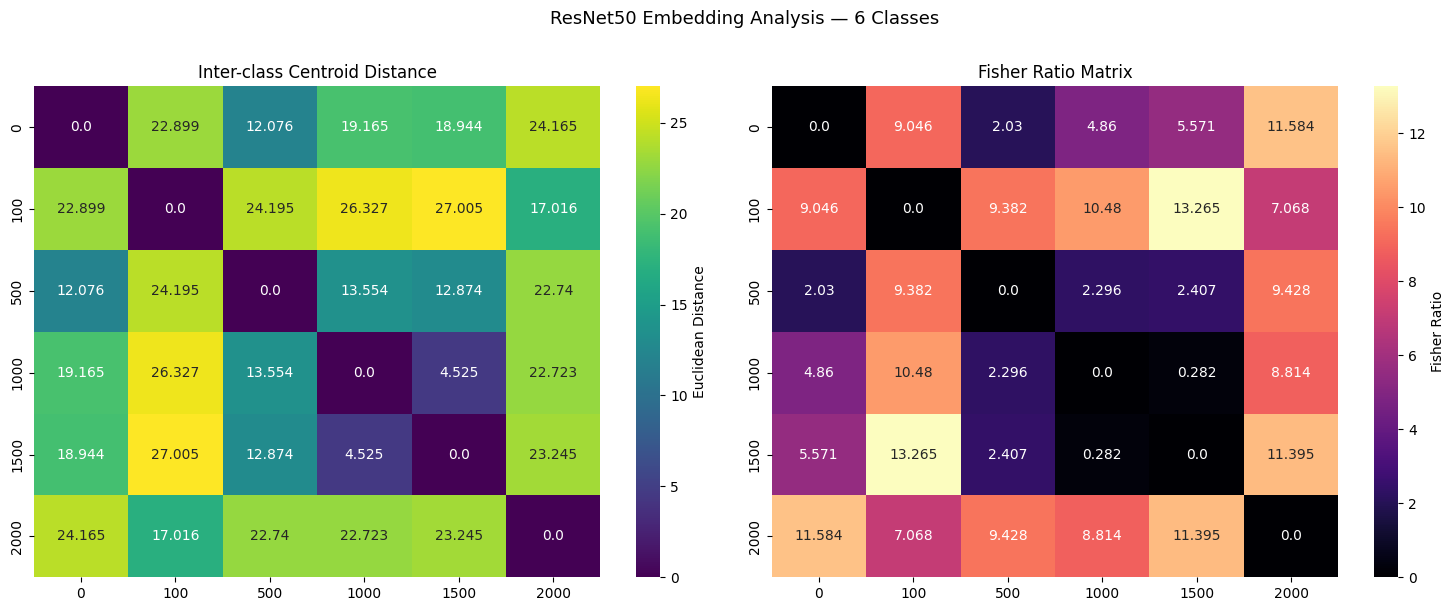

Saved: distance_fisher_side_by_side.png


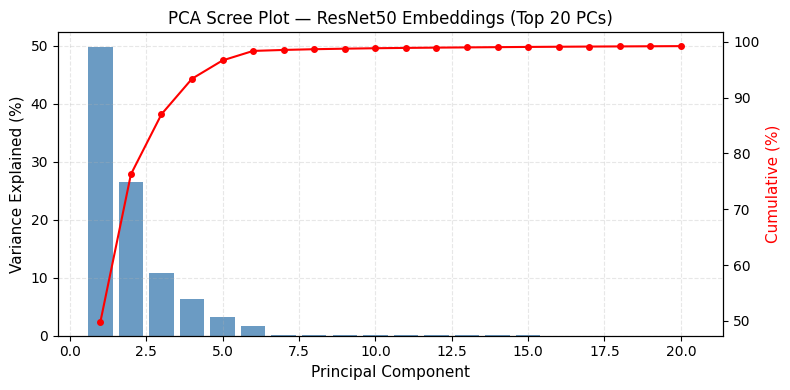

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_May11_Results/PCA_Analysis
PC1+PC2 explains : 76.3%
PCs for 95% var  : 5


In [9]:
# ================================================
# Cell 9 — PCA Analysis of Embeddings
# ================================================
# ── Additional libraries for PCA analysis ──────────────────────
# seaborn : heatmap visualisation for distance and Fisher matrices
# scipy   : pairwise Euclidean distances between class centroids
# sklearn.decomposition.PCA : dimensionality reduction for 2D plot
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# ── Load precomputed embeddings ────────────────────────────────
# Embeddings and predictions saved by Cells 7 and 6 are loaded
# here to decouple PCA analysis from training (can re-run independently).
# Load embeddings saved by Cell 7
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV saved by Cell 6
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 6 first."
pred_df   = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 128-d embeddings onto 2 principal components for
# visualisation. Well-separated clusters indicate the model has
# learned discriminative features for each milling class.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of ResNet50 Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# ── Inter-class centroid distance matrix ───────────────────────
# Euclidean distance between class mean embeddings in 128-d space.
# Large inter-class distances indicate well-separated representations.
# intra_spread measures average distance of samples from their centroid;
# small intra-spread means compact, consistent class clusters.
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — ResNet50 ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# ── Fisher Discriminant Ratio ──────────────────────────────────
# Fisher ratio = (inter-class distance)^2 / (sum of intra-class variances)
# High Fisher ratio between two classes means they are well-separated
# relative to their internal scatter — a good discriminability measure.
# ── Fisher ratio ────────────────────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)


# Combined distance + Fisher heatmaps side by side for the paper figure
# ── Side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'ResNet50 Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# ── PCA scree plot ─────────────────────────────────────────────
# Shows variance explained by each principal component (bar) and
# cumulative variance (red line). Used to determine how many PCs
# are needed to capture 95% of the embedding variance.
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4, label='Cumulative')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — ResNet50 Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA results to CSV for reproducibility and further analysis
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

print(f"\nAll PCA results saved to: {PCA_DIR}")
n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")